In [4]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image
import time
from tqdm import tqdm
import glob
from Resnet18 import ResNet18FC, DeepfakeDataset

In [5]:
def load_model_and_history(model_path):
    # Load training history
    with open(os.path.join(model_path, 'training_history.json'), 'r') as f:
        history = json.load(f)
    
    # Load model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ResNet18FC(num_classes=2)
    checkpoint = torch.load(os.path.join(model_path, 'best_model.pth'), map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    return model, history

In [6]:
def plot_training_metrics(history):
    plt.figure(figsize=(15, 10))
    
    # Plot accuracy
    plt.subplot(2, 2, 1)
    plt.plot(history['epochs'], history['train_acc'], label='Training Accuracy')
    plt.plot(history['epochs'], history['val_acc'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    # Plot loss
    plt.subplot(2, 2, 2)
    plt.plot(history['epochs'], history['train_loss'], label='Training Loss')
    plt.plot(history['epochs'], history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot learning rate
    plt.subplot(2, 2, 3)
    plt.plot(history['epochs'], history['learning_rate'])
    plt.title('Learning Rate')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

In [7]:
import torch
import numpy as np
from tqdm import tqdm
import time
import psutil
import os

try:
    import pyRAPL  # For CPU energy consumption
    pyRAPL.setup()
    rapl_available = True
except ImportError:
    print("⚠️ pyRAPL not installed, CPU energy consumption will be skipped.")
    rapl_available = False


def evaluate_model(model, test_loader, device):
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    # Setup profiling
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)
    process = psutil.Process(os.getpid())
    mem_before = process.memory_info().rss / (1024 ** 2)  # MB

    if rapl_available:
        meter = pyRAPL.Measurement("eval_model")
        meter.begin()

    clock_start_ns = time.perf_counter_ns()
    if device.type == "cuda":
        torch.cuda.synchronize()
    start_time = time.time()

    # Evaluation loop
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)

            # Predictions
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    if device.type == "cuda":
        torch.cuda.synchronize()
    end_time = time.time()
    clock_end_ns = time.perf_counter_ns()

    # Memory & Energy Usage
    if torch.cuda.is_available():
        mem_used = torch.cuda.max_memory_allocated(device) / (1024 ** 2)  # MB
        mem_type = "gpu_memory_mb"
    else:
        mem_after = process.memory_info().rss / (1024 ** 2)
        mem_used = mem_after - mem_before
        mem_type = "cpu_memory_mb"

    if rapl_available:
        meter.end()
        cpu_energy_joules = meter.result.pkg[0] / 1e6  # Convert µJ → J
    else:
        cpu_energy_joules = None

    total_inference_time = end_time - start_time
    inference_time_per_image = total_inference_time / total
    cpu_clock_cycles = clock_end_ns - clock_start_ns  # Nanoseconds

    accuracy = 100 * correct / total

    # Results dictionary
    results = {
        "accuracy": accuracy,
        "total_inference_time_sec": total_inference_time,
        "inference_time_per_image_sec": inference_time_per_image,
        mem_type: mem_used,
        "cpu_energy_joules": cpu_energy_joules,
        "cpu_clock_cycles_ns": cpu_clock_cycles,
    }

    print(f"\n✅ Evaluation completed.")
    for k, v in results.items():
        print(f"{k}: {v}")

    return accuracy, np.array(all_preds), np.array(all_labels), results


⚠️ pyRAPL not installed, CPU energy consumption will be skipped.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(y_true, y_pred, class_names=('0','1')):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))

    # Heatmap
    im = ax.imshow(cm, cmap='Blues')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Axis labels/ticks
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title('Confusion Matrix')

    # Annotate each cell with dynamic text color
    # Threshold at midrange of the displayed values
    thresh = (cm.max() + cm.min()) / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            txt_color = 'white' if val > thresh else 'black'
            ax.text(j, i, f'{val}', ha='center', va='center', color=txt_color, fontsize=12)

    plt.tight_layout()
    plt.show()

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))


In [14]:
# Set paths
model_dirs = glob.glob('model/densenet_kan_20250820_111345') 
if not model_dirs:
    raise FileNotFoundError("No model directories found")
model_path = max(model_dirs, key=os.path.getctime)

print(f"Using model from: {model_path}")

Using model from: model/densenet_kan_20250820_111345


In [16]:
# Load model and history
print("Loading model and training history...")
model, history = load_model_and_history(model_path)

Loading model and training history...

Layer Freezing Summary:
Frozen: Conv1 + Layer1 (shallow features)
Trainable: Deeper residual blocks + FC head


D:\tmp\ipykernel_11748\2376770568.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(model_path, 'best_model.pth'), map_location=device

Plotting training metrics...


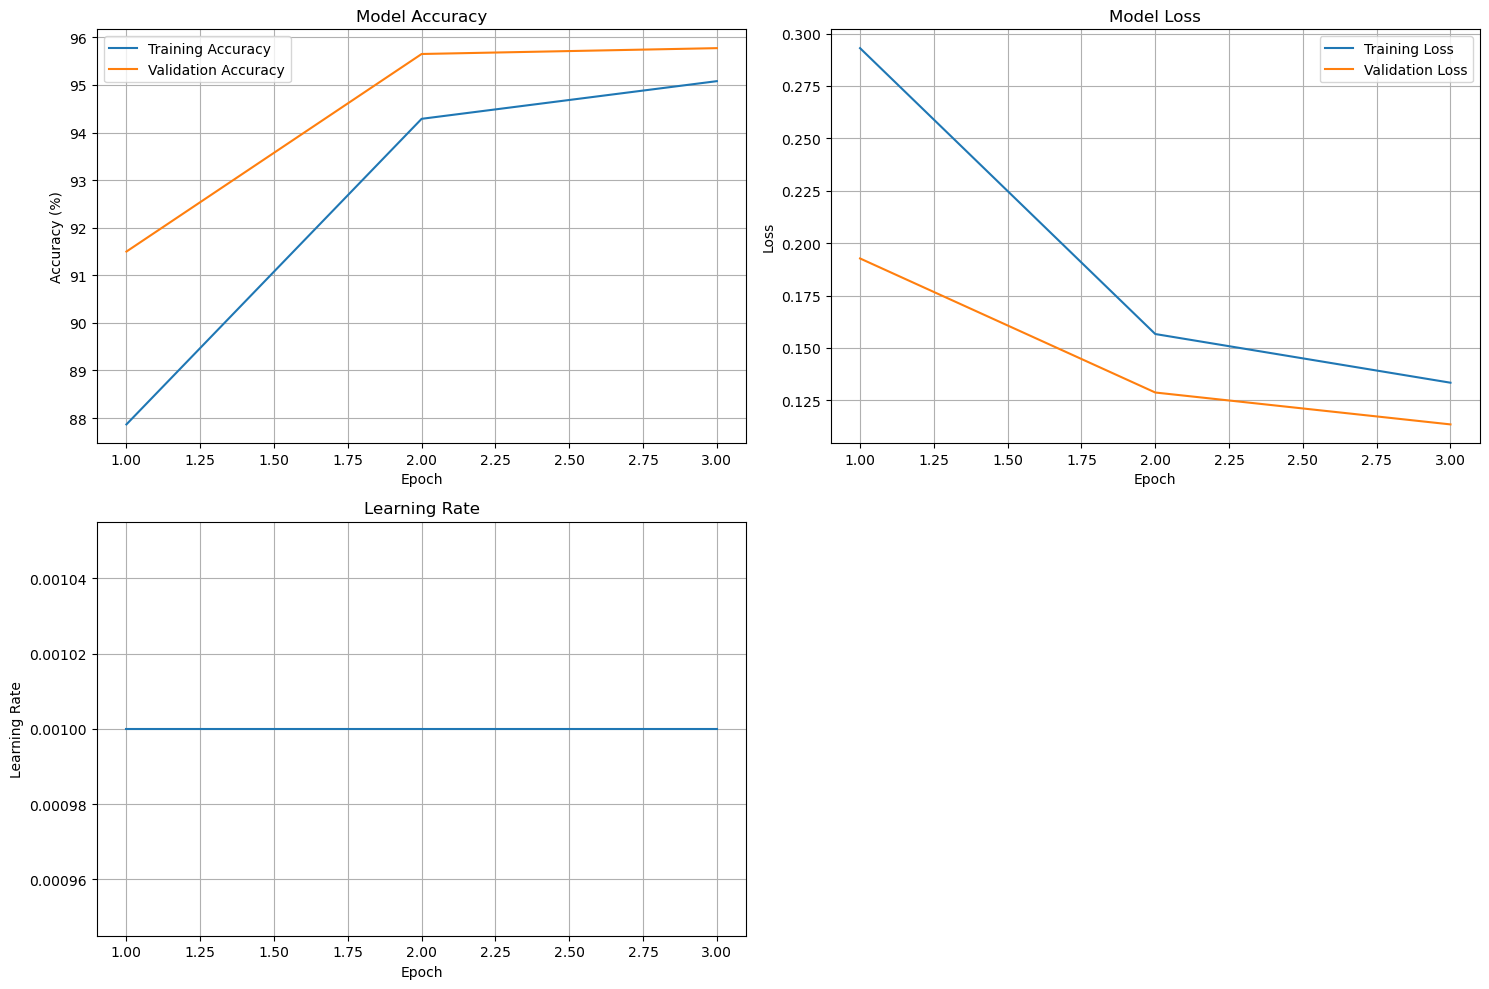

In [17]:
# Plot training metrics
print("Plotting training metrics...")
plot_training_metrics(history)

In [19]:
# Create test data loader
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = DeepfakeDataset('dataset_kaggle/dataset/data/test', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

Loading dataset from dataset_kaggle/dataset/data/test
Loading real images...
Loading fake images...
Loaded 4030 images in 1.14 seconds


In [24]:
# Evaluate model
print("Evaluating model on test set...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

test_accuracy, predictions, true_labels, results = evaluate_model(model, test_loader, device)

print(f"\nTest Accuracy: {test_accuracy:.2f}%")


Evaluating model on test set...


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 126/126 [00:44<00:00,  2.86it/s]


✅ Evaluation completed.
accuracy: 93.05210918114143
total_inference_time_sec: 44.09035873413086
inference_time_per_image_sec: 0.010940535666037435
gpu_memory_mb: 267.56640625
cpu_energy_joules: None
cpu_clock_cycles_ns: 44090278800

Test Accuracy: 93.05%



Generating confusion matrix for best performing weights...


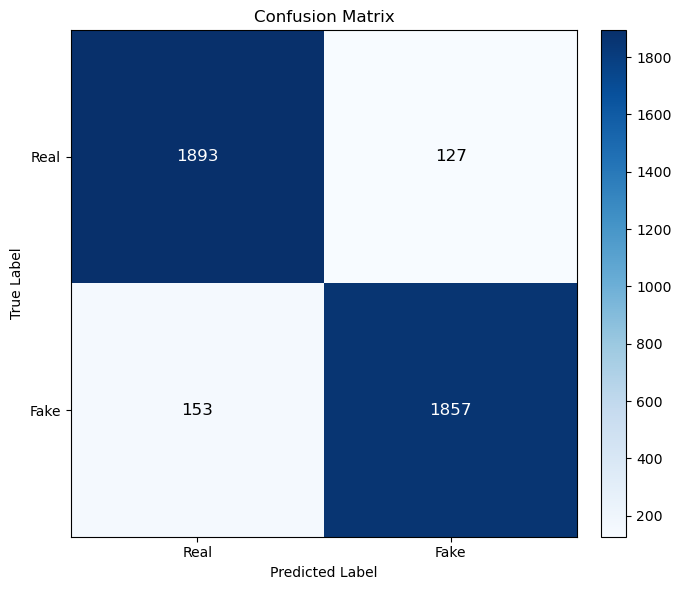


Classification Report:
              precision    recall  f1-score   support

        Real       0.93      0.94      0.93      2020
        Fake       0.94      0.92      0.93      2010

    accuracy                           0.93      4030
   macro avg       0.93      0.93      0.93      4030
weighted avg       0.93      0.93      0.93      4030



In [20]:
print("\nGenerating confusion matrix for best performing weights...")
plot_confusion_matrix(true_labels,predictions, class_names=['Real','Fake'])
# or ['Real','Fake'] if you prefer names
